n genes in adata with Ka/Ks: 16400


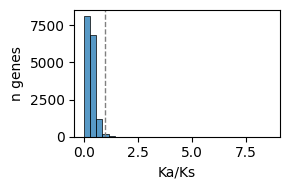

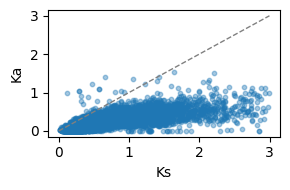

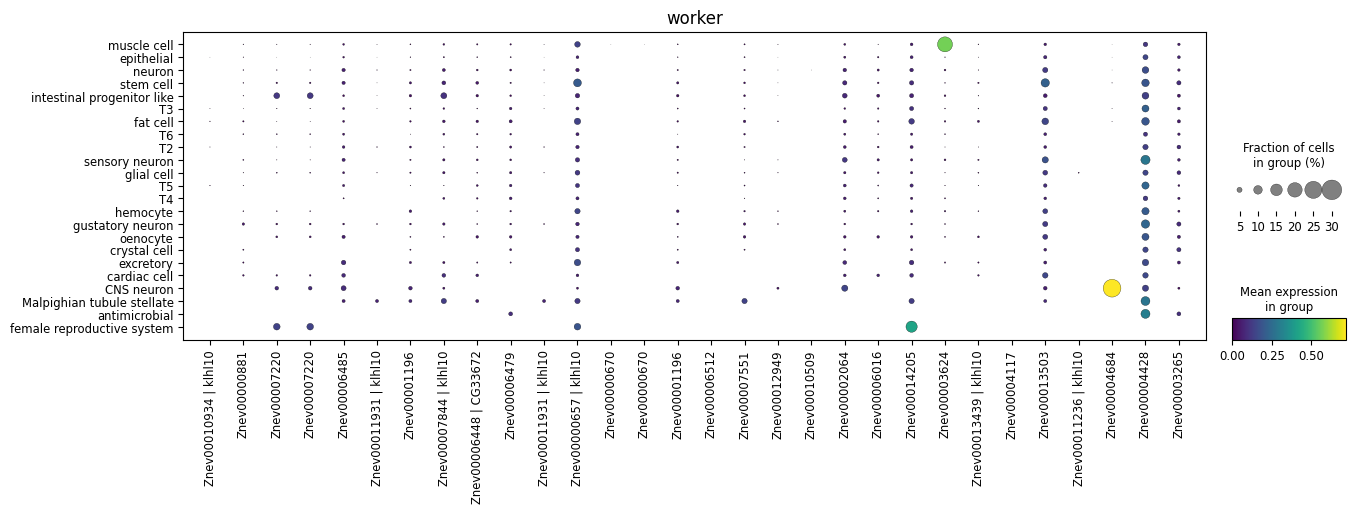

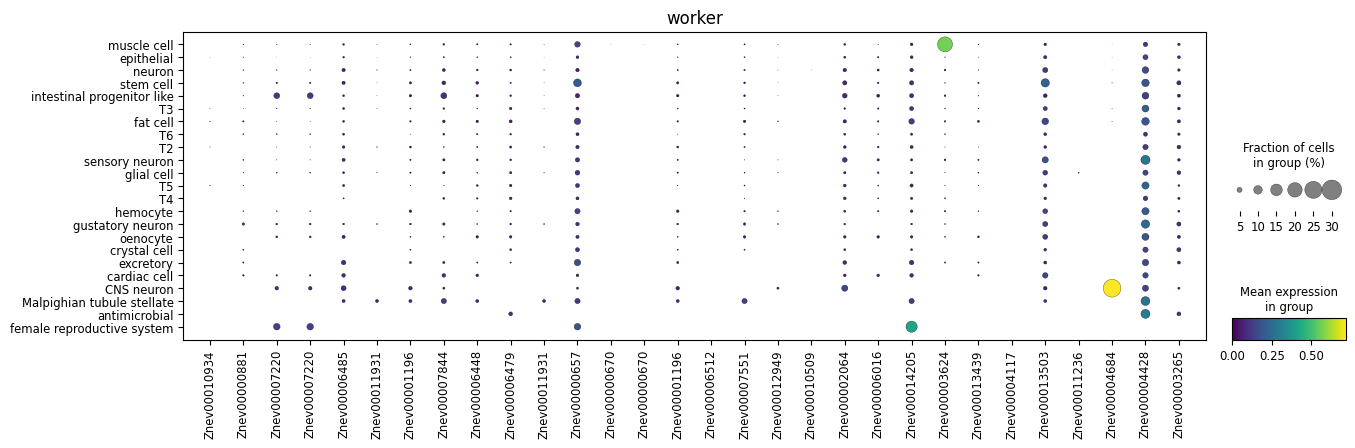

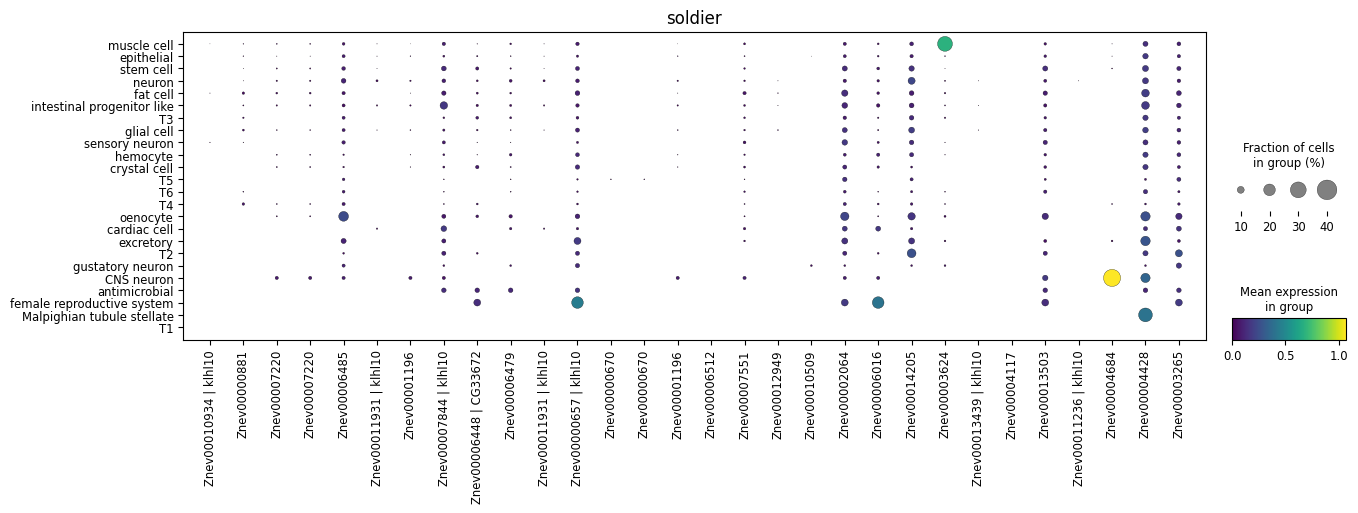

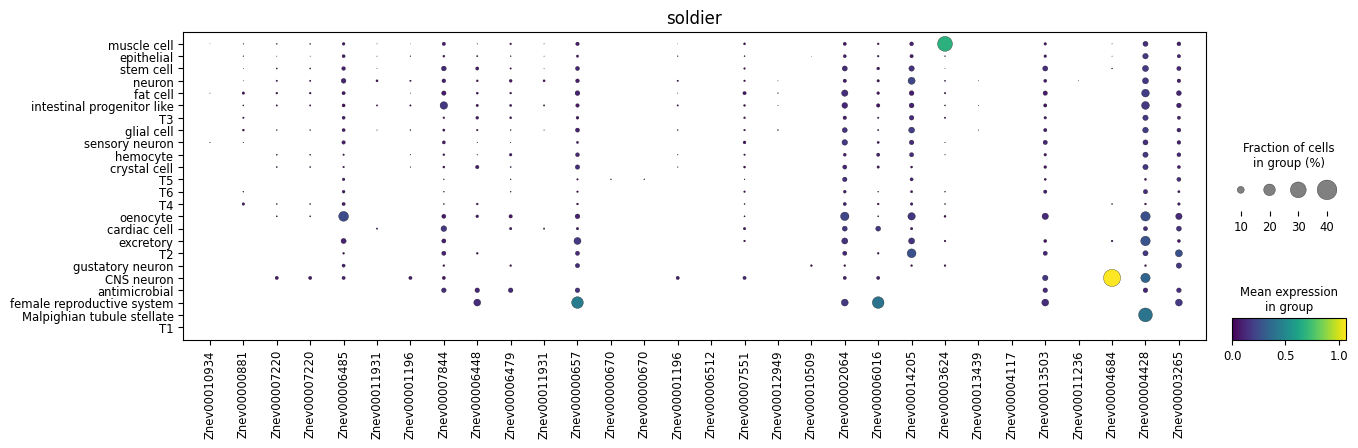

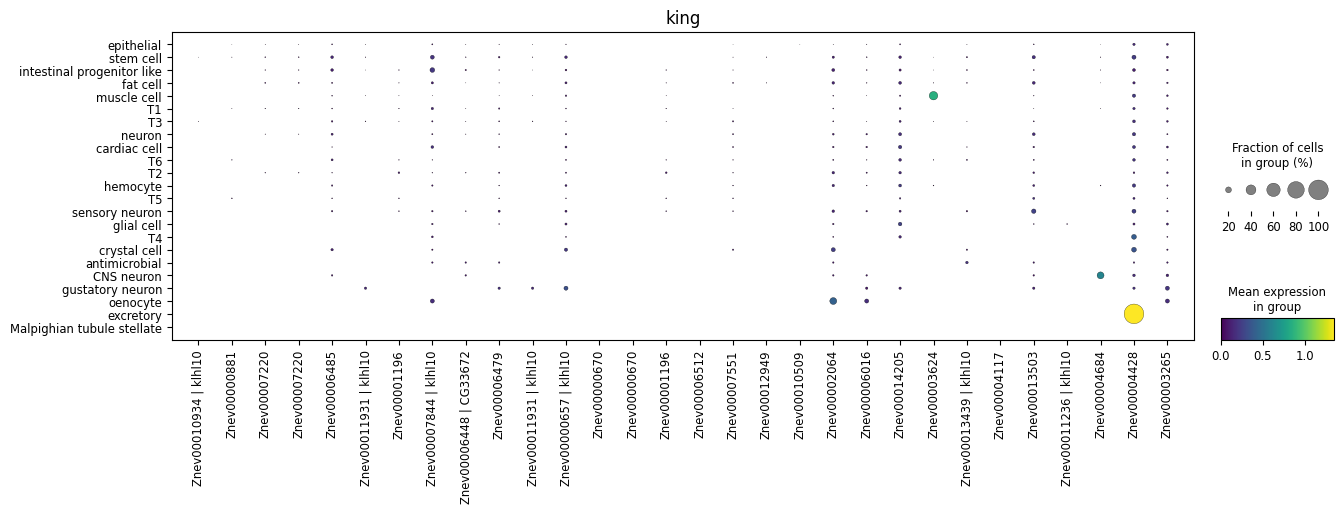

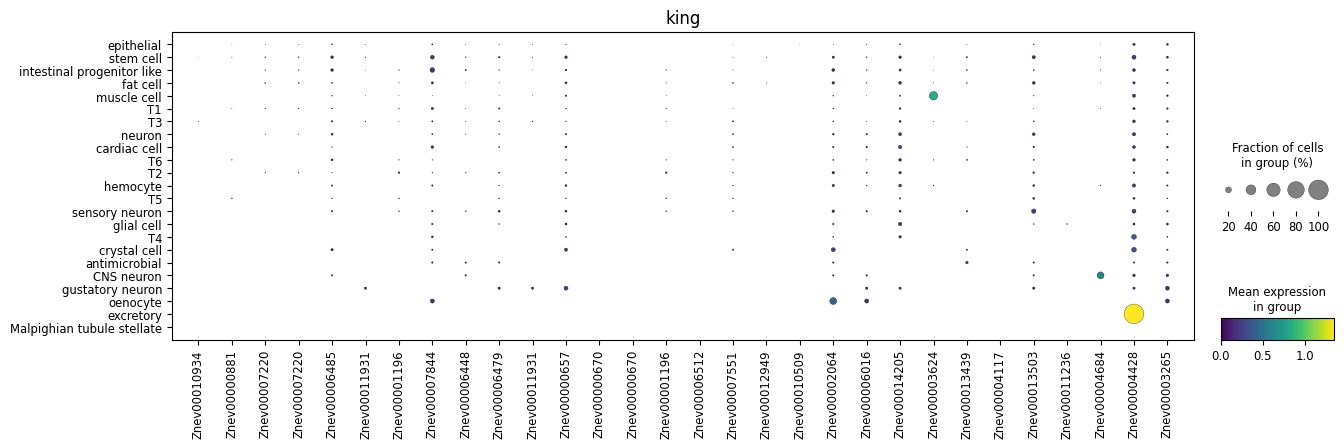

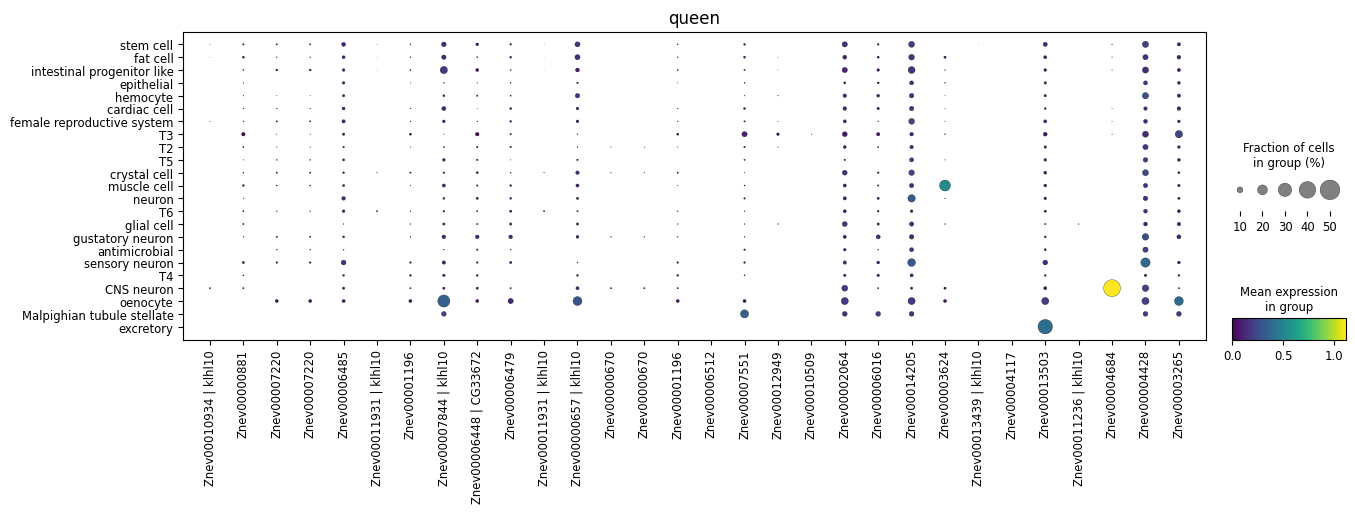

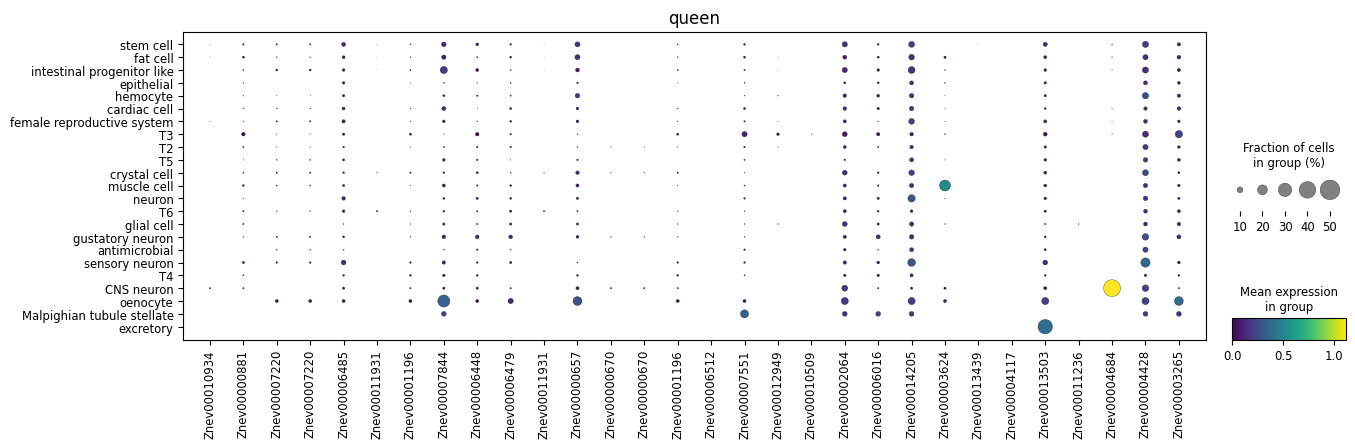

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# Load data
# -----------------------
h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)

dnds_value_file = "/home/catherine/phd/projects/termites/data/znev/Hsjo_vs_Znev.kaks"
dnds_df = pd.read_csv(dnds_value_file, sep="\t", header=None)
dnds_df.columns = ["seq1", "seq2", "Ks", "Ka", "variance_Ks", "variance_Ka"]

# -----------------------
# Parse gene IDs
# -----------------------
dnds_df["seq2_trim"] = dnds_df["seq2"].astype(str).str[:-3]
dnds_df["gene"] = dnds_df["seq2_trim"].str.split("-").str[0]

# -----------------------
# Compute Ka/Ks + filter
# -----------------------
dnds_df["Ka/Ks"] = (dnds_df["Ka"] + 1e-8) / (dnds_df["Ks"] + 1e-8)

dnds_df_filt = dnds_df.loc[dnds_df["Ka"] <= 3].copy()
dnds_df_filt = dnds_df_filt.loc[dnds_df_filt["Ks"] <= 3].copy()
dnds_df_filt = dnds_df_filt.loc[dnds_df_filt["gene"].isin(adata.var_names)].copy()

print("n genes in adata with Ka/Ks:", dnds_df_filt.shape[0])

# ============================================================
# PLOT 1) Distribution of Ka/Ks
# ============================================================
fig, ax = plt.subplots(figsize=(3, 2))
sns.histplot(dnds_df_filt["Ka/Ks"], bins=30, ax=ax)
ax.axvline(1.0, ls="--", color="grey", lw=1)
ax.set_xlabel("Ka/Ks")
ax.set_ylabel("n genes")
fig.tight_layout()

# ============================================================
# PLOT 2) Ka vs Ks scatter
# ============================================================
fig, ax = plt.subplots(figsize=(3, 2))
ax.scatter(dnds_df_filt["Ks"], dnds_df_filt["Ka"], s=10, alpha=0.4)
m = float(np.nanmax([dnds_df_filt["Ks"].max(), dnds_df_filt["Ka"].max()]))
ax.plot([0, m], [0, m], ls="--", color="grey", lw=1)
ax.set_xlabel("Ks")
ax.set_ylabel("Ka")
fig.tight_layout()

# ============================================================
# PLOT 3) One dotplot per caste
# ============================================================
celltype_col = "paper_cell_type_annotation"
caste_col = "caste"
caste_order = ["worker", "soldier", "king", "queen"]

topN = 30
top_genes = dnds_df_filt.nlargest(topN, "Ka/Ks")["gene"].tolist()

# build labels: ZnevID | ortholog  (if present)
gene_labels = {}
for g in top_genes:
    lab = g
    if "dmel_gene_ortho" in adata.var.columns and g in adata.var.index:
        ortho = adata.var.loc[g, "dmel_gene_symbol"]
        if pd.notna(ortho) and str(ortho).strip() not in ["", "nan", "NA"]:
            lab = f"{g} | {ortho}"
    gene_labels[g] = lab

for caste in caste_order:
    adata_c = adata[adata.obs[caste_col] == caste].copy()
    if adata_c.n_obs == 0:
        print(f"[skip] no cells for {caste}")
        continue

    celltype_order = (
        adata_c.obs[celltype_col]
        .value_counts()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    dp = sc.pl.dotplot(
        adata_c,
        var_names=top_genes,
        groupby=celltype_col,
        categories_order=celltype_order,
        color_map="viridis",
        figsize=(15, 4),
        dendrogram=False,
        show=False,
        return_fig=True,
        title=caste
    )

    ax_dict = dp.get_axes()
    if "mainplot_ax" in ax_dict:
        ax = ax_dict["mainplot_ax"]
        ax.set_xticklabels([gene_labels[g] for g in top_genes], rotation=90)

    dp.show()

plt.show()

In [2]:
adata

AnnData object with n_obs × n_vars = 24252 × 14272
    obs: 'sample#', 'caste', 'n_genes_by_counts', 'total_counts', 'leiden', 'samap_annot', 'labels_only_znev_fabio', 'leiden_fabio', 'leiden_dmel_fabio', 'znev_leiden_dmel_fabio', 'paper_cell_type_annotation', 'comparison_group'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'dmel_gene_ortho', 'dmel_gene_symbol'
    uns: 'annotate_cells_colors', 'annotations_1_colors', 'caste_colors', 'hvg', 'leiden', 'leiden_colors', 'leiden_dmel_fabio_colors', 'leiden_fabio_colors', 'log1p', 'neighbors', 'new_clusters_colors', 'paper_cell_type_annotation_colors', 'pca', 'rank_genes_groups', 'samap_annot_colors', 'umap', 'znev_leiden_dmel_fabio_colors'
    obsm: 'X_pca', 'X_umap', 'X_umap_fabio'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# start with all genes missing
dnds_series = pd.Series(np.nan, index=adata.var_names, name="Ka/Ks")

# fill genes that have Ka/Ks values from your dnds table
tmp = (
    dnds_df_filt[["gene", "Ka/Ks"]]
    .drop_duplicates(subset="gene")
    .set_index("gene")["Ka/Ks"]
)

common = dnds_series.index.intersection(tmp.index)
dnds_series.loc[common] = tmp.loc[common]

cats = pd.Series(index=adata.var_names, dtype="object")
cats[dnds_series.isna()] = "Missing dN/dS"
cats[dnds_series < 0.05] = "dN/dS < 0.05"
cats[(dnds_series >= 0.05) & (dnds_series <= 1.1)] = "0.05 ≤ dN/dS ≤ 1.1"
cats[dnds_series > 1.1] = "dN/dS > 1.1"

category_order = [
    "Missing dN/dS",
    "dN/dS < 0.05",
    "0.05 ≤ dN/dS ≤ 1.1",
    "dN/dS > 1.1",
]

counts = cats.value_counts().reindex(category_order, fill_value=0)
percentages = counts / len(adata.var_names) * 100

summary_df = pd.DataFrame({
    "category": category_order,
    "n_genes": counts.values,
    "percent_of_all_adata_genes": percentages.values
})

print(summary_df)



             category  n_genes  percent_of_all_adata_genes
0       Missing dN/dS     2838                   19.885090
1        dN/dS < 0.05      690                    4.834641
2  0.05 ≤ dN/dS ≤ 1.1    10705                   75.007007
3         dN/dS > 1.1       39                    0.273262


n genes Missing dN/dS   : 2838
n genes dN/dS < 0.05    : 690
n genes 0.05–1.1        : 10705
n genes dN/dS > 1.1     : 39


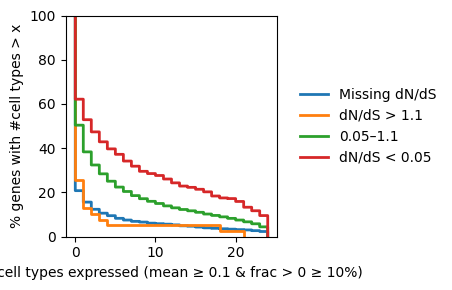

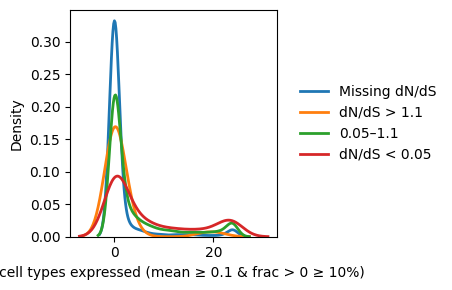

In [4]:
# -----------------------
# Gene sets from cats / dnds_series
# -----------------------
genes_missing = cats.index[cats == "Missing dN/dS"].tolist()
genes_lo      = cats.index[cats == "dN/dS < 0.05"].tolist()
genes_mid     = cats.index[cats == "0.05 ≤ dN/dS ≤ 1.1"].tolist()
genes_hi      = cats.index[cats == "dN/dS > 1.1"].tolist()

print("n genes Missing dN/dS   :", len(genes_missing))
print("n genes dN/dS < 0.05    :", len(genes_lo))
print("n genes 0.05–1.1        :", len(genes_mid))
print("n genes dN/dS > 1.1     :", len(genes_hi))

# -----------------------
# For each gene: number of cell types where
# mean log expr >= 0.1 AND fraction of expressing cells (x>0) >= 10%
# -----------------------
celltype_col = "paper_cell_type_annotation"
cts = adata.obs[celltype_col].cat.categories

def _n_celltypes_expressed(glist, mean_thr=0.1, frac_thr=0.10):
    if len(glist) == 0:
        return np.array([])
    out = []
    for g in glist:
        if g not in adata.var_names:
            continue
        n_ok = 0
        for ct in cts:
            sub = adata[adata.obs[celltype_col] == ct, g]
            x = sub.X
            if hasattr(x, "toarray"):
                x = x.toarray()
            x = np.asarray(x).ravel()
            if np.mean(x) >= mean_thr and (np.mean(x > 0) >= frac_thr):
                n_ok += 1
        out.append(n_ok)
    return np.array(out, dtype=float)

nct_missing = _n_celltypes_expressed(genes_missing, mean_thr=0.1, frac_thr=0.10)
nct_hi      = _n_celltypes_expressed(genes_hi,      mean_thr=0.1, frac_thr=0.10)
nct_mid     = _n_celltypes_expressed(genes_mid,     mean_thr=0.1, frac_thr=0.10)
nct_lo      = _n_celltypes_expressed(genes_lo,      mean_thr=0.1, frac_thr=0.10)



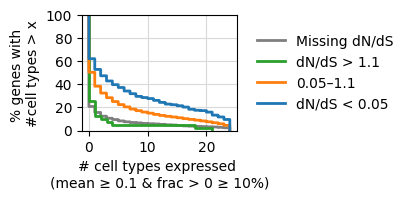

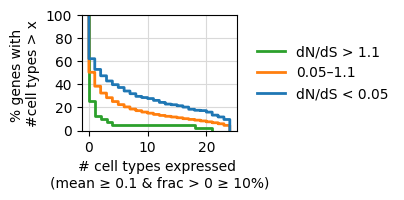

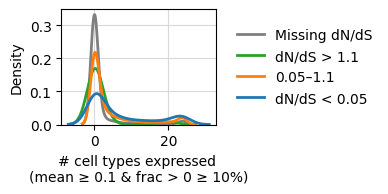

In [43]:
# same colours for all plots
color_dict = {
    "Missing dN/dS": "#7f7f7f",
    "dN/dS < 0.05": "#1f77b4",
    "0.05 ≤ dN/dS ≤ 1.1": "#ff7f0e",
    "dN/dS > 1.1": "#2ca02c",
}

# -----------------------
# ECDF (complementary) — with missing
# -----------------------
fig, ax = plt.subplots(figsize=(2.0, 1.5))

if nct_missing.size:
    ax.ecdf(
        nct_missing, complementary=True, lw=2,
        label="Missing dN/dS",
        color=color_dict["Missing dN/dS"]
    )

if nct_hi.size:
    ax.ecdf(
        nct_hi, complementary=True, lw=2,
        label="dN/dS > 1.1",
        color=color_dict["dN/dS > 1.1"]
    )

if nct_mid.size:
    ax.ecdf(
        nct_mid, complementary=True, lw=2,
        label="0.05–1.1",
        color=color_dict["0.05 ≤ dN/dS ≤ 1.1"]
    )

if nct_lo.size:
    ax.ecdf(
        nct_lo, complementary=True, lw=2,
        label="dN/dS < 0.05",
        color=color_dict["dN/dS < 0.05"]
    )

ax.set_xlabel("# cell types expressed \n(mean ≥ 0.1 & frac > 0 ≥ 10%)")
ax.set_ylabel("% genes with \n#cell types > x")
ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{int(v*100)}" for v in np.linspace(0, 1, 6)])
ax.grid(True, color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.05, 0.5))
plt.savefig("dcf_dnds_missing.png", dpi=600)
#fig.tight_layout()
# -----------------------
# ECDF (complementary) — no missing
# -----------------------
fig, ax = plt.subplots(figsize=(2.0, 1.5))

if nct_hi.size:
    ax.ecdf(
        nct_hi, complementary=True, lw=2,
        label="dN/dS > 1.1",
        color=color_dict["dN/dS > 1.1"]
    )

if nct_mid.size:
    ax.ecdf(
        nct_mid, complementary=True, lw=2,
        label="0.05–1.1",
        color=color_dict["0.05 ≤ dN/dS ≤ 1.1"]
    )

if nct_lo.size:
    ax.ecdf(
        nct_lo, complementary=True, lw=2,
        label="dN/dS < 0.05",
        color=color_dict["dN/dS < 0.05"]
    )

ax.set_xlabel("# cell types expressed \n(mean ≥ 0.1 & frac > 0 ≥ 10%)")
ax.set_ylabel("% genes with \n#cell types > x")
ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{int(v*100)}" for v in np.linspace(0, 1, 6)])
ax.grid(True, color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.05, 0.5))
plt.savefig("dcf_dnds.png", dpi=600)
#fig.tight_layout()

# -----------------------
# KDE
# -----------------------
fig, ax = plt.subplots(figsize=(2.0, 1.5))

if nct_missing.size:
    sns.kdeplot(
        nct_missing, ax=ax, lw=2,
        label="Missing dN/dS",
        color=color_dict["Missing dN/dS"]
    )

if nct_hi.size:
    sns.kdeplot(
        nct_hi, ax=ax, lw=2,
        label="dN/dS > 1.1",
        color=color_dict["dN/dS > 1.1"]
    )

if nct_mid.size:
    sns.kdeplot(
        nct_mid, ax=ax, lw=2,
        label="0.05–1.1",
        color=color_dict["0.05 ≤ dN/dS ≤ 1.1"]
    )

if nct_lo.size:
    sns.kdeplot(
        nct_lo, ax=ax, lw=2,
        label="dN/dS < 0.05",
        color=color_dict["dN/dS < 0.05"]
    )

ax.set_xlabel("# cell types expressed \n(mean ≥ 0.1 & frac > 0 ≥ 10%)")
ax.set_ylabel("Density")
ax.grid(True, color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.05, 0.5))
plt.savefig("dcf_dnds_missing_density.png", dpi=600)
#fig.tight_layout()

plt.show()